# Usage

This notebook does simple analysis on ROOT file output from SuperCDMS SuperSim DMC simulations.

The particular simulation analyzed here is CUTE Tower 3 with Ba133 source, defined by `simulation_jobs/CUTE-T3_Ba133_12inch_DMC_tuned.mac`. And the main focus is on the Silicon detectors (detectors 2 and 5).

Main objectives:
- Estimate energy point of saturation in the Silicon detectors
- Create method for plotting energy sharing between channels

Requirements:
- Ensure you are using a SuperCDMS module Apptainer kernel to run this notebook
- *(Note: Only module release version V07-00 was tested during this notebook's development)*

## Imports

In [6]:
# Loading ROOT files
from cats.cdataframe import CDataFrame

# System paths
import sys
from pathlib import Path

# -------------------------------------
# Set your clone's source file root
# -------------------------------------
project_root = Path("/home/nevenac/projects/scdms-dmc/src")
sys.path.append(str(project_root))

# DMC output access utilities
from dmc_utils import (
    list_detector_events,
    get_traces_for_events,
    flip_traces,
    normalize_traces,
    get_trace_t_y
)

# Vector math
import numpy as np

# Dictionary manipulation
from collections import defaultdict
import pandas as pd

# Plotting
%matplotlib inline
import matplotlib.pyplot as plt

# -------------------------------------
# Debugging mode
# -------------------------------------
DEBUG = 1

## Load DMC data

In [3]:
# Set path to DMC ROOT file and check is valid
file_path = Path("/home/nevenac/projects/scdms-dmc/output/CUTE-T3_Ba133_12inch_DMC_1Mevents/combined.root")
print(f"File exists? {file_path.exists()}")

File exists? True


In [4]:
# Get and display detector-event index
index = list_detector_events(file_path, "G4SimDir/g4dmcTES", unique=True)


G4SimDir/g4dmcTES Detector -> Event Summary
Det 1: 926 events
   [3, 6, 9, 10, 13, 18, 21, 25, 10001, 10003] ...
Det 2: 407 events
   [2, 15, 19, 20, 22, 10006, 10014, 10015, 10019, 10023] ...
Det 3: 585 events
   [0, 1, 4, 5, 11, 24, 26, 10002, 10005, 10008] ...
Det 4: 676 events
   [8, 12, 14, 16, 23, 10000, 10007, 10010, 10020, 20000] ...
Det 5: 352 events
   [7, 17, 27, 10018, 10020, 10025, 20001, 20009, 20013, 20015] ...
Det 6: 345 events
   [10012, 10024, 20003, 20020, 30004, 30006, 30016, 30020, 30022, 40005] ...


## Get TES traces for all events that occured in silicon detectors

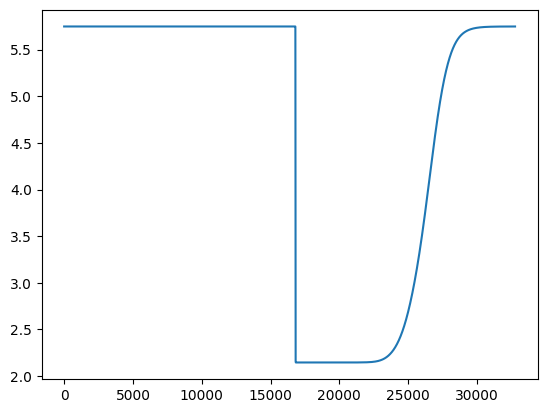

In [5]:
# Define silicon detector IDs
silicon_detectors = [2, 5]

# Show one plot as sanity check
show_trace = True

# Load TES traces for events in silicon detectors
events = []
for det in silicon_detectors:
    events += index[det]
data = get_traces_for_events(str(file_path), events, silicon_detectors)   # CDataFrame takes a string path
# data is a dict of NumPy arrays, aligned by index: {"Trace": [...], "ChanNum": [...], ...}

if show_trace:
    show_trace = False      # Show only on first loop
    traces = data["Trace"]
    plt.plot(traces[0])
    plt.show


In [8]:
# Combine traces from all silicon detectors into a single event list
# Flatten the dictionary values into a list of trace data dicts, each item in the list corresponds to a detector-event
all_event_bundles = []

df_dict = {}
for key, value in data.items():
    # Ensure every trace in Trace is treated as an array object 
    # It will be entered as one object in the dataframe's Trace column
    df_dict[key] = list(value) if key == "Trace" else value

temp_df = pd.DataFrame(df_dict)
if DEBUG: print(temp_df.head)

# Group by EventNum (within this detector) and aggregate into lists
event_groups = temp_df.groupby(['EventNum', 'DetNum']).agg(list).reset_index()

# Convert to list of dicts and add to our master list
# Each element in the list corresponds to one row in the original DataFrame
all_event_bundles.extend(event_groups.to_dict('records'))

# Check how many detector-events were found
print(f"Number of Detector-Events found: {len(all_event_bundles)}")

# Visually inspect first event dict in the event list
if DEBUG: print(*(f"{k}: {v}\n" for k, v in all_event_bundles[0].items()), sep="")

# Validation: verify each event has 12 traces, warn if any are found otherwise
for event in all_event_bundles:
    if len(event['Trace']) != 12:
        print(f"WARNING: Event {event['EventNum']} has {len(event['Trace'])} traces.")

<bound method NDFrame.head of       EventNum  DetNum  ChanNum ChanName  \
0          2.0     2.0      0.0     PFS1   
1          2.0     2.0      1.0     PCS1   
2          2.0     2.0      2.0     PDS1   
3          2.0     2.0      3.0     PBS1   
4          2.0     2.0      4.0     PES1   
...        ...     ...      ...      ...   
9103  990027.0     5.0      7.0     PCS2   
9104  990027.0     5.0      8.0     PBS2   
9105  990027.0     5.0      9.0     PES2   
9106  990027.0     5.0     10.0     PDS2   
9107  990027.0     5.0     11.0     PAS2   

                                                  Trace          T0  BinWidth  
0     [5.747870020514144, 5.747870018732498, 5.74787... -26880000.0    1600.0  
1     [3.7265421813467285, 3.7265421785914143, 3.726... -26880000.0    1600.0  
2     [4.650931012429622, 4.650931010427378, 4.65093... -26880000.0    1600.0  
3     [4.860780628694291, 4.8607806327297105, 4.8607... -26880000.0    1600.0  
4     [5.125778938434903, 5.1257789387897

## Get total event energy proxies

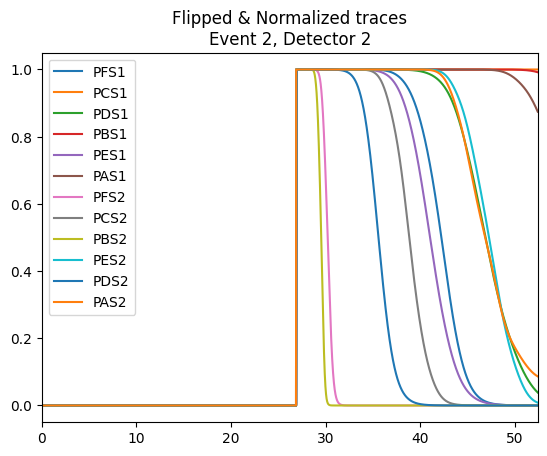

In [29]:
# Integrate over traces to get a total energy proxy and examine the energy distribution

# Show first trace after flip and normalization
show_trace = True

for evt in all_event_bundles:
    # Dont mutate input events
    traces = [t.copy() for t in evt["Trace"]]

    eventNum = int(evt["EventNum"])
    detNum = int(evt["DetNum"][0])
    channels = evt["ChanName"]
    bins = evt["BinWidth"]

    # Ensure bins are all the same and assign this as dt
    bins_unique = list(np.unique(bins))
    if len(bins_unique) > 1:
        print(f"Warning: Varying bin sizes found for event traces {evt["EventNum"][0]} in detector {evt["DetNum"][0]}")
        break
    dt = bins[0]

    # Flip traces and normalize 
    # Note, normalize is done by (trace - min_val) / (max_val - min_val)
    traces = flip_traces(traces)
    traces = normalize_traces(traces)

    # Sanity check modified traces for first event
    if show_trace:
        show_trace = False      # Show only on first loop
        for i, trace in enumerate(traces):
            t, y = get_trace_t_y(
                trace,
                dt=dt
            )
            plt.plot(t, y, label=channels[i])
        plt.title(f"Flipped & Normalized traces\nEvent {eventNum}, Detector {detNum}")
        plt.xlim(t.min(), t.max())
        plt.legend()
        plt.show()

    # Add modified traces to event data
    evt["FlipNormTrace"] = traces

    # For each event, integrate all 12 traces and sum them 
    # This is a proxy for the total energy deposited in the detector for that event
    evt["TotalEnergyProxy"] = sum(
        np.trapezoid(trace, dx=dt) 
        for trace in traces
    )

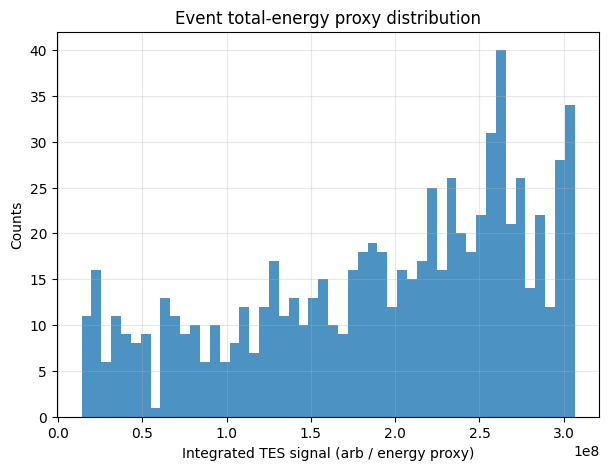

In [24]:
# Plot histogram energy distribution
energies = [evt["TotalEnergyProxy"] for evt in all_event_bundles]

plt.figure(figsize=(7,5))
plt.hist(energies, bins=50, alpha=0.8)
plt.xlabel("Integrated TES signal (arb / energy proxy)")
plt.ylabel("Counts")
plt.title("Event total-energy proxy distribution")
plt.grid(alpha=0.3)

plt.show()

## Determine saturation point

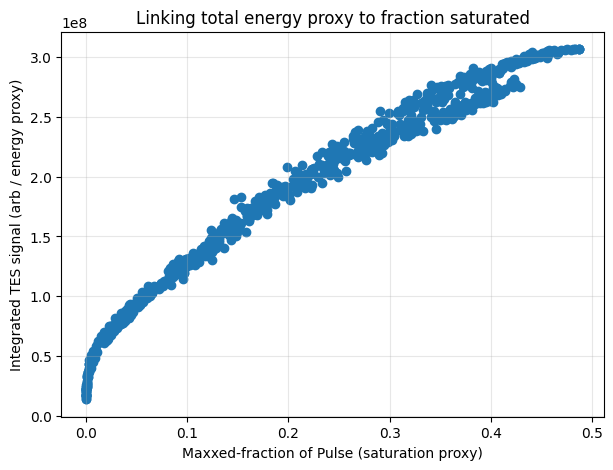

In [31]:
# Method for determining if a trace is saturated

# Get percentage of bins that have full saturation (==1) for normalized traces
# The number of bins that are maxxed will vary per event
# Count number of maxxed bins for each event and add this metric to its data dict
for evt in all_event_bundles:
    # Convert list of 12 traces into a 2D NumPy array (12, samples)
    traces_matrix = np.array(evt["FlipNormTrace"])
    
    # Use small tolerance or >= to catch saturated values
    # This creates a boolean mask of the same shape as traces_matrix
    is_saturated = traces_matrix >= 0.999 
    
    # Sum all True values across the entire event
    max_value_counts = np.sum(is_saturated)
    
    # Calculate fraction
    # Total possible points = (Number of traces) * (Samples per trace)
    total_possible_points = traces_matrix.size 
    
    evt["MaxValCounts"] = max_value_counts
    evt["FractionMax"] = max_value_counts / total_possible_points

# Plot energy proxy versus fraction saturated
energies    = [evt["TotalEnergyProxy"] for evt in all_event_bundles]
fractionSat = [evt["FractionMax"] for evt in all_event_bundles]

plt.figure(figsize=(7,5))
plt.scatter(fractionSat, energies)
plt.xlabel("Maxxed-fraction of Pulse (saturation proxy)")
plt.ylabel("Integrated TES signal (arb / energy proxy)")
plt.title("Linking total energy proxy to fraction saturated")
plt.grid(alpha=0.3)

plt.show()

## Link energy proxy to actual Edep

In [ ]:
# Load g4dmcHits
# Filter trueEnergy or trueEdx by events that occurred in silicon detectors
hitsData = 

# Plot energy proxy versus actual energy deposited (edep)

In [10]:
# Plot fraction saturated versus actual energy deposited (edep)